In [94]:
from cmath import nan

import pandas as pd
from sklearn.datasets import load_iris
import seaborn as sns
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,r2_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression


In [79]:
iris = load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names)
data["target"] = iris.target
print(data.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [80]:
data.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

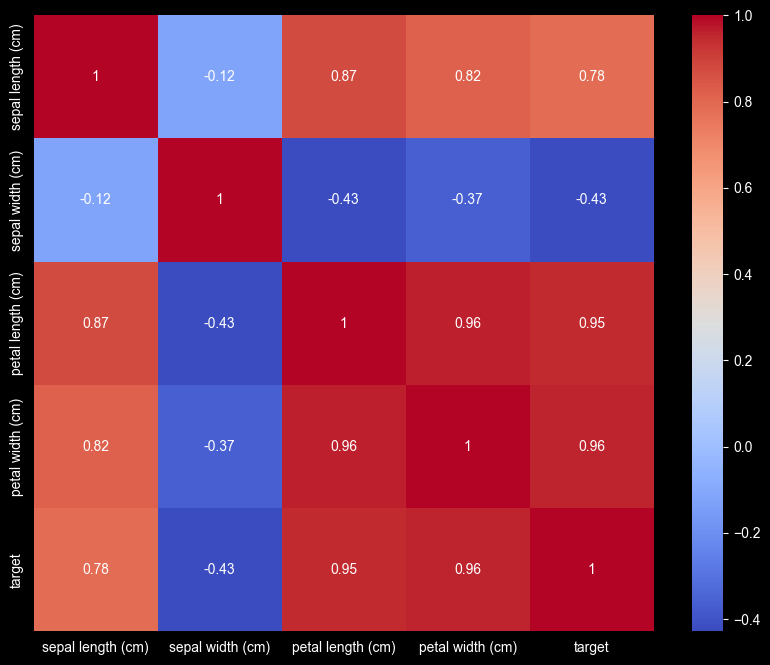

In [81]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()

In [82]:
ft=data.drop("target",axis=1)
tr=data["target"]
x_train,x_test,y_train,y_test=train_test_split(ft,tr,test_size=0.2,random_state=42)

In [83]:
model=LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accurcy_l=round(accuracy_score(y_test,y_pred)*100,2)
percesion_l=round(precision_score(y_test,y_pred, average="macro")*100,2)
recall_l=round(recall_score(y_test,y_pred, average="macro")*100,2)
print("confition metric : \n",confusion_matrix(y_test,y_pred))

confition metric : 
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [84]:
model=DecisionTreeClassifier()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accurcy_d=round(accuracy_score(y_test,y_pred)*100,2)
percesion_d=round(precision_score(y_test,y_pred, average="macro")*100,2)
recall_d=round(recall_score(y_test,y_pred, average="macro")*100,2)
print("confition metric : \n",confusion_matrix(y_test,y_pred))

confition metric : 
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [85]:
model=RandomForestClassifier()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accurcy_f=round(accuracy_score(y_test,y_pred)*100,2)
percesion_f=round(precision_score(y_test,y_pred, average="macro")*100,2)
recall_f=round(recall_score(y_test,y_pred, average="macro")*100,2)
print("confition metric : \n",confusion_matrix(y_test,y_pred))

confition metric : 
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [86]:
model=KNeighborsClassifier()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accurcy_k=round(accuracy_score(y_test,y_pred)*100,2)
percesion_k=round(precision_score(y_test,y_pred, average="macro")*100,2)
recall_k=round(recall_score(y_test,y_pred, average="macro")*100,2)
print("confition metric : \n",confusion_matrix(y_test,y_pred))

confition metric : 
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [88]:
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
f1=r2_score(y_test,y_pred)
print(f1)

0.9468960016420045


In [92]:
dic={
    "model_name":["logistic_regretion","Decession_tree","Random_forest","KNN"],
    "accurcy":[accurcy_l,accurcy_d,accurcy_f,accurcy_k],
    "precision":[percesion_l,percesion_d,percesion_f,percesion_k],
    "recall":[recall_l,recall_d,recall_f,recall_k]

}

In [93]:
model_info=pd.DataFrame(dic)
model_info.sort_values(by="accurcy",ascending=False,inplace=True)
print(model_info)

           model_name  accurcy  precision  recall
0  logistic_regretion    100.0      100.0   100.0
1      Decession_tree    100.0      100.0   100.0
2       Random_forest    100.0      100.0   100.0
3                 KNN    100.0      100.0   100.0


In [95]:
fig=px.bar(model_info,x="model_name",y="accurcy",color="model_name")
fig.show()